
# FullSubNet Curriculum Learning Ablation Study

## Research Objective

Systematically compare **fixed SNR training** against **epoch-wise SNR curriculum schedules** for FullSubNet to determine which training strategy best improves:
1. Perceptual quality (**PESQ**)
2. Intelligibility (**STOI**)
3. Signal quality (**SI-SNR**)
4. Generalization to **unseen noise**

## Core idea

`FullSubNetDataset` already supports curriculum learning through:
- `use_snr_curriculum=True`
- `snr_curriculum=[(start_epoch, end_epoch, (snr_min, snr_max)), ...]`
- `set_epoch(epoch)` to update the train-time SNR range each epoch

This notebook keeps the **evaluation SNR range fixed across all experiments** for fair comparison, while varying only the **training SNR schedule**.



## How to Use This Notebook

### Recommended workflow
1. Start with the **fixed-range baselines**
2. Run the **easy-to-hard curriculum**
3. Run the **widening-range curriculum**
4. Optionally run the **hard-to-easy control**

### Important fairness note
Because `FullSubNetDataset` uses `default_snr_range` to generate **fixed validation/test pairs**, you should keep **`EVAL_SNR_RANGE` constant across all experiments**. Only the **training SNR schedule** should change.

### Suggested experiment set
- `fixed_snr_0_10`
- `fixed_snr_neg5_15`
- `curriculum_easy_to_hard`
- `curriculum_widening_range`
- `curriculum_hard_to_easy_control` (optional control)


## Setup and Imports

In [1]:

import os
import sys
import json
import random
import inspect
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm import tqdm

# Setup paths for modules
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Project imports
from src.data.manifest import load_manifest
from src.data.dataset import FullSubNetDataset
from src.models.fullsubnet import FullSubNet
from src.training.losses import SISNRLoss
from src.evaluation.evaluate import evaluate_model
from src.evaluation.metrics import validate_with_metrics

print("✓ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


✓ Dataset classes defined
✓ Loss functions defined
✓ All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True


In [2]:

# Configure plotting
sns.set_theme(style="whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda



## Configuration: Curriculum Experiments

This notebook uses a **shared FullSubNet architecture and optimization setup** and changes only the **training SNR policy**.

### Evaluation fairness
- **Training SNR**: varies per experiment
- **Validation/Test SNR**: fixed to `EVAL_SNR_RANGE`

### SNR schedule format
Each curriculum is a list of:
```python
(start_epoch, end_epoch, (snr_min, snr_max))
```


In [3]:

# ============================================================================
# CURRICULUM LEARNING ABLATION CONFIGURATION
# ============================================================================

SKIP_COMPLETED = True
TRACK_TIME_METRICS = True

# TODO: Delete this after
# Keep evaluation fixed across all experiments for fairness
# EVAL_SNR_RANGE = (0, 10)

BASE_MODEL_CONFIG = {
    "n_fft": 512,
    "hop_length": 128,
    "win_length": 512,
    "num_freqs": 257,
    "freq_cutoffs": (16, 96),
    "sb_num_center_freqs": (1, 4, 8),
    "sb_num_neighbor_freqs": (7, 7, 7),
    "fb_num_center_freqs": (1, 4, 8),
    "fb_num_neighbor_freqs": (7, 7, 7),
    "fb_hidden_size": 512,
    "sb_hidden_size": 384,
    "sequence_model": "LSTM",
    "dropout": 0.2,
    "norm_type": "cumulative_laplace_norm",
}

BASE_TRAINING_CONFIG = {
    "epochs": 40,
    "batch_size": 8,
    "learning_rate": 3e-4,
    "weight_decay": 1e-5,
    "patience": 10,
    "gradient_clip": 5.0,
    "augmentation_factor": 5,
    "eval_pairs": 3,
    "seed": 42,
}

# Note: train_snr_range is the default train range. If curriculum is enabled,
# FullSubNetDataset will override it epoch-by-epoch using snr_curriculum.
EXPERIMENTS = [
    # {
    #     "experiment_name": "fixed_snr_0_10",
    #     "description": "No curriculum; moderate fixed train range",
    #     "train_snr_range": (0, 10),
    #     "use_snr_curriculum": False,
    #     "snr_curriculum": None,
    # },
    {
        "experiment_name": "fixed_snr_neg5_20",
        "description": "No curriculum; broad fixed train range",
        "train_snr_range": (-5, 20),
        "use_snr_curriculum": False,
        "snr_curriculum": None,
    },
    {
        "experiment_name": "curriculum_easy_to_hard",
        "description": "Start easy, gradually increase noise difficulty",
        "train_snr_range": (10, 20),
        "use_snr_curriculum": True,
        "snr_curriculum": [
            (1, 10, (10, 20)),
            (11, 20, (5, 15)),
            (21, 30, (0, 10)),
            (31, 40, (-5, 5)),
        ],
    },
    {
        "experiment_name": "curriculum_widening_range",
        "description": "Start narrow and gradually widen the train SNR range",
        "train_snr_range": (5, 10),
        "use_snr_curriculum": True,
        "snr_curriculum": [
            (1, 10, (5, 10)),
            (11, 20, (0, 10)),
            (21, 30, (-5, 10)),
            (31, 40, (-5, 15)),
        ],
    },
    {
        "experiment_name": "curriculum_hard_to_easy_control",
        "description": "Control experiment: reverse curriculum to test order effects",
        "train_snr_range": (-5, 5),
        "use_snr_curriculum": True,
        "snr_curriculum": [
            (1, 10, (-5, 5)),
            (11, 20, (0, 10)),
            (21, 30, (5, 15)),
            (31, 40, (10, 20)),
        ],
    },
]

# If compute is limited, replace with a subset, e.g. EXPERIMENTS[:4]
ACTIVE_EXPERIMENTS = EXPERIMENTS

RESULTS_ROOT = PROJECT_ROOT / "results" / "fullsubnet_curriculum_ablation"
PLOTS_ROOT = PROJECT_ROOT / "plots" / "fullsubnet_curriculum_ablation"

print(f"Total configured experiments: {len(ACTIVE_EXPERIMENTS)}")
for exp in ACTIVE_EXPERIMENTS:
    print(f"  - {exp['experiment_name']}: {exp['description']}")


Total configured experiments: 4
  - fixed_snr_neg5_20: No curriculum; broad fixed train range
  - curriculum_easy_to_hard: Start easy, gradually increase noise difficulty
  - curriculum_widening_range: Start narrow and gradually widen the train SNR range
  - curriculum_hard_to_easy_control: Control experiment: reverse curriculum to test order effects


## Utility Functions

In [4]:

import time
import psutil

def set_seed(seed: int):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def setup_experiment_dirs(experiment_name: str):
    """Create experiment directories."""
    results_dir = RESULTS_ROOT / experiment_name
    checkpoint_dir = results_dir / "checkpoints"
    plots_dir = PLOTS_ROOT / experiment_name

    results_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)
    return results_dir, checkpoint_dir, plots_dir


def save_experiment_config(config: Dict, save_path: Path):
    with open(save_path, "w") as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)


def is_experiment_complete(results_dir: Path) -> bool:
    return (results_dir / "evaluation_results.json").exists()


def clear_gpu_memory():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()


def get_gpu_memory_gb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1e9


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def summarize_schedule(schedule: Optional[List[Tuple[int, int, Tuple[int, int]]]]) -> str:
    if schedule is None:
        return "None"
    return " | ".join([f"e{a}-{b}:{r}" for a, b, r in schedule])

print("✓ Utility functions defined")


✓ Utility functions defined


## Dataset Loading (Curriculum-aware FullSubNetDataset)

In [5]:

def create_datasets(manifest_dict: Dict, experiment_cfg: Dict, base_cfg: Dict) -> Dict:
    """Create curriculum-aware datasets for a single experiment."""
    seed = base_cfg["seed"]
    aug_factor = base_cfg["augmentation_factor"]
    eval_pairs = base_cfg["eval_pairs"]

    train_snr_range = tuple(experiment_cfg["train_snr_range"])
    use_snr_curriculum = experiment_cfg["use_snr_curriculum"]
    snr_curriculum = experiment_cfg["snr_curriculum"]

    print(f"  Train SNR default: {train_snr_range}")
    print(f"  Curriculum enabled: {use_snr_curriculum}")
    if use_snr_curriculum:
        print(f"  Schedule: {summarize_schedule(snr_curriculum)}")

    datasets = {}

    datasets["train"] = FullSubNetDataset(
        clean_files=manifest_dict["train"],
        noise_files=manifest_dict["noise_seen"],
        mode="train",
        snr_range=train_snr_range,
        augmentation_factor=aug_factor,
        base_seed=seed,
        epoch=1,
        use_snr_curriculum=use_snr_curriculum,
        snr_curriculum=snr_curriculum,
    )

    datasets["val_seen"] = FullSubNetDataset(
        clean_files=manifest_dict["val"],
        noise_files=manifest_dict["noise_seen"],
        mode="val",
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed,
    )

    datasets["val_unseen"] = FullSubNetDataset(
        clean_files=manifest_dict["val"],
        noise_files=manifest_dict["noise_unseen"],
        mode="val",
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 1,
    )

    datasets["test_seen"] = FullSubNetDataset(
        clean_files=manifest_dict["test"],
        noise_files=manifest_dict["noise_seen"],
        mode="test",
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 2,
    )

    datasets["test_unseen"] = FullSubNetDataset(
        clean_files=manifest_dict["test"],
        noise_files=manifest_dict["noise_unseen"],
        mode="test",
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 3,
    )

    print(f"  ✓ Datasets created: {sum(len(d) for d in datasets.values())} total pairs")
    return datasets


def create_dataloaders(datasets: Dict, batch_size: int) -> Dict:
    loaders = {
        "train": DataLoader(datasets["train"], batch_size=batch_size, shuffle=True, num_workers=0),
        "val_seen": DataLoader(datasets["val_seen"], batch_size=batch_size, shuffle=False, num_workers=0),
        "val_unseen": DataLoader(datasets["val_unseen"], batch_size=batch_size, shuffle=False, num_workers=0),
        "test_seen": DataLoader(datasets["test_seen"], batch_size=batch_size, shuffle=False, num_workers=0),
        "test_unseen": DataLoader(datasets["test_unseen"], batch_size=batch_size, shuffle=False, num_workers=0),
    }
    return loaders

print("✓ Curriculum-aware dataset functions defined")


✓ Curriculum-aware dataset functions defined


## Model Creation

In [6]:

def create_model(model_cfg: Dict, device: torch.device) -> nn.Module:
    """Create FullSubNet while passing only supported constructor args."""
    sig = inspect.signature(FullSubNet.__init__)
    kwargs = {k: v for k, v in model_cfg.items() if k in sig.parameters}

    model = FullSubNet(**kwargs).to(device)
    print(f"  Model created: {count_parameters(model):,} trainable parameters")
    print(f"  Sequence model: {model_cfg.get('sequence_model', 'LSTM')}")
    print(f"  Norm type: {model_cfg.get('norm_type', 'offline_laplace_norm')}")
    print(f"  Dropout: {model_cfg.get('dropout', 'n/a')}")
    return model

print("✓ Model creation function defined")


✓ Model creation function defined


## Loss and Metric Helpers

In [7]:
def build_criterion() -> nn.Module:
    return SISNRLoss()


print("✓ Loss and metric helpers defined")


✓ Loss and metric helpers defined


## Training Functions

In [8]:

def train_epoch(model, loader, criterion, optimizer, device, gradient_clip=5.0, track_time=False):
    """Train for one epoch with optional timing."""
    model.train()
    total_loss = 0.0
    epoch_start = time.time()

    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        noisy = batch["noisy"].to(device)
        clean = batch["clean"].to(device)

        enhanced = model(noisy)
        if enhanced.dim() == 3 and enhanced.size(1) == 1:
            enhanced = enhanced.squeeze(1)

        loss = criterion(enhanced, clean)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.6f}"})

    epoch_time = time.time() - epoch_start
    result = {"avg_loss": total_loss / max(len(loader), 1)}
    if track_time:
        result["epoch_time"] = epoch_time
        result["gpu_memory_gb"] = get_gpu_memory_gb()
    return result


def initialize_history(track_time=False) -> Dict:
    history = {
        "train_loss": [],
        "val_seen_loss": [],
        "val_unseen_loss": [],
        "val_seen_pesq": [],
        "val_unseen_pesq": [],
        "val_seen_stoi": [],
        "val_unseen_stoi": [],
        "val_seen_si_snr": [],
        "val_unseen_si_snr": [],
        "generalization_gap_pesq": [],
        "generalization_gap_stoi": [],
        "generalization_gap_si_snr": [],
        "train_snr_min": [],
        "train_snr_max": [],
        "lr": [],
    }
    if track_time:
        history["epoch_time"] = []
        history["gpu_memory_gb"] = []
    return history


def run_training(model, loaders, datasets, criterion, optimizer, scheduler,
                 training_cfg: Dict, checkpoint_dir: Path, device: torch.device,
                 experiment_cfg: Dict, track_time=False):
    """Run complete curriculum-learning training loop."""
    history = initialize_history(track_time=track_time)
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    training_start = time.time()

    num_epochs = training_cfg["epochs"]
    patience = training_cfg.get("patience", 10)
    grad_clip = training_cfg.get("gradient_clip", 5.0)

    print(f"\n  Training for {num_epochs} epochs (patience={patience})")
    print("  " + "=" * 70)

    for epoch in range(1, num_epochs + 1):
        # IMPORTANT: curriculum update happens here
        datasets["train"].set_epoch(epoch)
        current_snr_range = tuple(datasets["train"].snr_range)

        print(f"\n  Epoch {epoch}/{num_epochs} | Train SNR: {current_snr_range}", end=" ")

        train_result = train_epoch(
            model, loaders["train"], criterion, optimizer, device,
            gradient_clip=grad_clip, track_time=track_time
        )
        train_loss = train_result["avg_loss"]

        val_seen = validate_with_metrics(
            model, loaders['val_seen'], criterion, device, max_pesq_samples=50
        )
        val_unseen = validate_with_metrics(
            model, loaders['val_unseen'], criterion, device, max_pesq_samples=50
        )

        scheduler.step(val_seen["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        gap_pesq = val_seen["pesq"] - val_unseen["pesq"]
        gap_stoi = val_seen["stoi"] - val_unseen["stoi"]
        gap_si_snr = val_seen["si_snr"] - val_unseen["si_snr"]

        history["train_loss"].append(train_loss)
        history["val_seen_loss"].append(val_seen["loss"])
        history["val_unseen_loss"].append(val_unseen["loss"])
        history["val_seen_pesq"].append(val_seen["pesq"])
        history["val_unseen_pesq"].append(val_unseen["pesq"])
        history["val_seen_stoi"].append(val_seen["stoi"])
        history["val_unseen_stoi"].append(val_unseen["stoi"])
        history["val_seen_si_snr"].append(val_seen["si_snr"])
        history["val_unseen_si_snr"].append(val_unseen["si_snr"])
        history["generalization_gap_pesq"].append(gap_pesq)
        history["generalization_gap_stoi"].append(gap_stoi)
        history["generalization_gap_si_snr"].append(gap_si_snr)
        history["train_snr_min"].append(current_snr_range[0])
        history["train_snr_max"].append(current_snr_range[1])
        history["lr"].append(current_lr)

        if track_time:
            history["epoch_time"].append(train_result.get("epoch_time", 0.0))
            history["gpu_memory_gb"].append(train_result.get("gpu_memory_gb", 0.0))

        print(
            f"| Loss: {train_loss:.4f} | "
            f"PESQ: {val_seen['pesq']:.2f}/{val_unseen['pesq']:.2f} | "
            f"STOI: {val_seen['stoi']:.3f}/{val_unseen['stoi']:.3f} | "
            f"SI-SNR: {val_seen['si_snr']:.2f}/{val_unseen['si_snr']:.2f}",
            end=""
        )

        if val_seen["loss"] < best_val_loss:
            best_val_loss = val_seen["loss"]
            epochs_without_improvement = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
                "best_val_loss": best_val_loss,
                "history": history,
                "experiment_cfg": experiment_cfg,
                "training_cfg": training_cfg,
                "model_cfg": BASE_MODEL_CONFIG,
            }, checkpoint_dir / "best_model.pth")
            print(" ✓", end="")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\n\n  Early stopping after {epoch} epochs")
            break

    total_training_time = time.time() - training_start
    print(f"\n\n  ✓ Training complete! Best val loss: {best_val_loss:.6f}")
    if track_time:
        print(f"  Total training time: {total_training_time / 60:.1f} minutes")

    return history, best_val_loss, total_training_time

print("✓ Training functions defined")


✓ Training functions defined


## Evaluation and Saving

In [9]:
def run_final_evaluation(model, loaders, checkpoint_dir: Path, results_dir: Path, device: torch.device, criterion):
    """Load best model and evaluate on seen/unseen test sets."""
    checkpoint = torch.load(checkpoint_dir / "best_model.pth", map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

    print("\n  Evaluating on test sets...")
   # Evaluate
    results_seen, results_unseen = evaluate_model(model, loaders['test_seen'], None, results_dir, device)
    
    return results_seen, results_unseen

print("✓ Evaluation functions defined")


✓ Evaluation functions defined


## Visualization Functions

In [10]:

def plot_training_curves(history: Dict, plots_dir: Path, exp_name: str, track_time=False):
    """Plot curriculum-specific training curves."""
    sns.set_style("whitegrid")
    sns.set_palette("husl")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0, 0].plot(epochs, history["train_loss"], label="Train", linewidth=2, marker='o', markersize=3)
    axes[0, 0].plot(epochs, history["val_seen_loss"], label="Val (Seen)", linewidth=2, marker='s', markersize=3)
    axes[0, 0].plot(epochs, history["val_unseen_loss"], label="Val (Unseen)", linewidth=2, marker='^', markersize=3)
    axes[0, 0].set_title("Training and Validation Loss", fontweight='bold')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend(framealpha=0.9)
    axes[0, 0].grid(True, alpha=0.3)

    # PESQ
    axes[0, 1].plot(epochs, history["val_seen_pesq"], label="Seen", linewidth=2.5, marker='o')
    axes[0, 1].plot(epochs, history["val_unseen_pesq"], label="Unseen", linewidth=2.5, marker='s')
    axes[0, 1].set_title("PESQ", fontweight='bold')
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Score")
    axes[0, 1].legend(framealpha=0.9)
    axes[0, 1].grid(True, alpha=0.3)

    # STOI
    axes[0, 2].plot(epochs, history["val_seen_stoi"], label="Seen", linewidth=2.5, marker='o')
    axes[0, 2].plot(epochs, history["val_unseen_stoi"], label="Unseen", linewidth=2.5, marker='s')
    axes[0, 2].set_title("STOI", fontweight='bold')
    axes[0, 2].set_xlabel("Epoch")
    axes[0, 2].set_ylabel("Score")
    axes[0, 2].legend(framealpha=0.9)
    axes[0, 2].grid(True, alpha=0.3)

    # SI-SNR
    axes[1, 0].plot(epochs, history["val_seen_si_snr"], label="Seen", linewidth=2.5, marker='o')
    axes[1, 0].plot(epochs, history["val_unseen_si_snr"], label="Unseen", linewidth=2.5, marker='s')
    axes[1, 0].set_title("SI-SNR", fontweight='bold')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("dB")
    axes[1, 0].legend(framealpha=0.9)
    axes[1, 0].grid(True, alpha=0.3)

    # Generalization gaps
    axes[1, 1].plot(epochs, history["generalization_gap_pesq"], label="PESQ Gap", linewidth=2.5, marker='o')
    axes[1, 1].plot(epochs, history["generalization_gap_stoi"], label="STOI Gap", linewidth=2.5, marker='s')
    axes[1, 1].plot(epochs, history["generalization_gap_si_snr"], label="SI-SNR Gap", linewidth=2.5, marker='^')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.6)
    axes[1, 1].set_title("Generalization Gaps (Seen - Unseen)", fontweight='bold')
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Gap")
    axes[1, 1].legend(framealpha=0.9)
    axes[1, 1].grid(True, alpha=0.3)

    # Train SNR schedule
    axes[1, 2].fill_between(epochs, history["train_snr_min"], history["train_snr_max"], alpha=0.35)
    axes[1, 2].plot(epochs, history["train_snr_min"], linewidth=2, marker='o', label='Train SNR min')
    axes[1, 2].plot(epochs, history["train_snr_max"], linewidth=2, marker='s', label='Train SNR max')
    axes[1, 2].set_title("Training SNR Range by Epoch", fontweight='bold')
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("SNR (dB)")
    axes[1, 2].legend(framealpha=0.9)
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle(f"Curriculum Ablation: {exp_name}", fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(plots_dir / f"{exp_name}_training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

print("✓ Visualization functions defined")


✓ Visualization functions defined


## Main Experiment Runner

In [11]:

def merge_experiment_config(experiment_cfg: Dict) -> Dict:
    config = {
        "experiment_name": experiment_cfg["experiment_name"],
        "description": experiment_cfg["description"],
        "seed": BASE_TRAINING_CONFIG["seed"],
        "model": BASE_MODEL_CONFIG,
        "training": BASE_TRAINING_CONFIG,
        "data": {
            "train_snr_range": experiment_cfg["train_snr_range"],
            # "eval_snr_range": EVAL_SNR_RANGE,
            "use_snr_curriculum": experiment_cfg["use_snr_curriculum"],
            "snr_curriculum": experiment_cfg["snr_curriculum"],
            "augmentation_factor": BASE_TRAINING_CONFIG["augmentation_factor"],
            "eval_pairs": BASE_TRAINING_CONFIG["eval_pairs"],
        },
    }
    return config


def run_single_experiment(experiment_cfg: Dict, manifest_dict: Dict, device: torch.device, track_time: bool = False):
    config = merge_experiment_config(experiment_cfg)
    exp_name = config["experiment_name"]

    clear_gpu_memory()
    set_seed(config["seed"])
    results_dir, checkpoint_dir, plots_dir = setup_experiment_dirs(exp_name)

    print(f"\n{'=' * 80}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"Description: {config['description']}")
    print(f"{'=' * 80}")

    if SKIP_COMPLETED and is_experiment_complete(results_dir):
        print("  ⊙ Experiment already completed, skipping...")
        return

    save_experiment_config(config, results_dir / "config.yaml")

    datasets = create_datasets(manifest_dict, experiment_cfg, BASE_TRAINING_CONFIG)
    loaders = create_dataloaders(datasets, BASE_TRAINING_CONFIG["batch_size"])

    model = create_model(BASE_MODEL_CONFIG, device)
    criterion = build_criterion()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BASE_TRAINING_CONFIG["learning_rate"],
        weight_decay=BASE_TRAINING_CONFIG.get("weight_decay", 1e-5),
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    history, best_val_loss, total_training_time = run_training(
        model, loaders, datasets, criterion, optimizer, scheduler,
        BASE_TRAINING_CONFIG, checkpoint_dir, device, experiment_cfg, track_time=track_time
    )

    with open(results_dir / "training_history.json", "w") as f:
        json.dump(history, f, indent=2)

    results_seen, results_unseen = run_final_evaluation(model, loaders, checkpoint_dir, results_dir, device, criterion)
    plot_training_curves(history, plots_dir, exp_name, track_time=track_time)

    print(f"\n  ✓ Experiment complete! Results saved to {results_dir}")
    if track_time:
        print(f"  Total time: {total_training_time / 60:.1f} minutes")
    print(f"  Final seen PESQ: {results_seen['pesq_mean']:.3f}")
    print(f"  Final seen SI-SNR: {results_seen['si_snr_mean']:.3f}")
    print(f"  Final unseen PESQ: {results_unseen['pesq_mean']:.3f}")
    print(f"  Final unseen SI-SNR: {results_unseen['si_snr_mean']:.3f}")

    clear_gpu_memory()

print("✓ Experiment runner defined")


✓ Experiment runner defined


## Load Shared Resources (Manifest)

In [12]:

MANIFEST_PATH = PROJECT_ROOT / "data" / "MANIFEST.json"

print("Loading manifest...")
manifest_dict = load_manifest(MANIFEST_PATH)

print("✓ Manifest loaded:")
print(f"  Train: {len(manifest_dict['train'])} files")
print(f"  Val: {len(manifest_dict['val'])} files")
print(f"  Test: {len(manifest_dict['test'])} files")
print(f"  Seen noise: {len(manifest_dict['noise_seen'])} files")
print(f"  Unseen noise: {len(manifest_dict['noise_unseen'])} files")


Loading manifest...
✓ Manifest loaded:
  Train: 160 files
  Val: 20 files
  Test: 20 files
  Seen noise: 38 files
  Unseen noise: 22 files


## Run All Curriculum Experiments

In [13]:

import traceback

print("\n" + "#" * 80)
print("# RUNNING FULLSUBNET CURRICULUM ABLATION EXPERIMENTS")
print("#" * 80)
print(f"\nTotal experiments: {len(ACTIVE_EXPERIMENTS)}")
print(f"Device: {DEVICE}")
print(f"Skip completed: {SKIP_COMPLETED}")
print(f"Track time metrics: {TRACK_TIME_METRICS}")
# print(f"Fixed evaluation SNR range: {EVAL_SNR_RANGE}")

start_time = datetime.now()

for i, experiment_cfg in enumerate(ACTIVE_EXPERIMENTS, 1):
    print(f"\n\n{'#' * 80}")
    print(f"# EXPERIMENT {i}/{len(ACTIVE_EXPERIMENTS)}: {experiment_cfg['experiment_name']}")
    print(f"{'#' * 80}")

    clear_gpu_memory()
    try:
        run_single_experiment(experiment_cfg, manifest_dict, DEVICE, track_time=TRACK_TIME_METRICS)
    except Exception as e:
        print(f"\n  ❌ Experiment failed with error: {e}")
        traceback.print_exc()
        print("  Continuing to next experiment...\n")
    finally:
        clear_gpu_memory()

end_time = datetime.now()
duration = end_time - start_time

print("\n\n" + "#" * 80)
print("# ALL CURRICULUM EXPERIMENTS COMPLETE")
print("#" * 80)
print(f"\nTotal time: {duration}")
print(f"Results saved to: {RESULTS_ROOT}")



################################################################################
# RUNNING FULLSUBNET CURRICULUM ABLATION EXPERIMENTS
################################################################################

Total experiments: 4
Device: cuda
Skip completed: True
Track time metrics: True


################################################################################
# EXPERIMENT 1/4: fixed_snr_neg5_20
################################################################################

EXPERIMENT: fixed_snr_neg5_20
Description: No curriculum; broad fixed train range
  Train SNR default: (-5, 20)
  Curriculum enabled: False
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (-5, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Gene

| Loss: -9.6722 | PESQ: 2.50/2.38 | STOI: 0.928/0.926 | SI-SNR: 12.85/12.96 ✓
  Epoch 2/40 | Train SNR: (-5, 20) 

| Loss: -12.6729 | PESQ: 2.51/2.37 | STOI: 0.935/0.934 | SI-SNR: 14.83/13.82 ✓
  Epoch 3/40 | Train SNR: (-5, 20) 

| Loss: -14.4249 | PESQ: 2.66/2.46 | STOI: 0.938/0.936 | SI-SNR: 15.68/14.51 ✓
  Epoch 4/40 | Train SNR: (-5, 20) 

| Loss: -15.3165 | PESQ: 2.65/2.48 | STOI: 0.936/0.936 | SI-SNR: 15.52/14.76 ✓
  Epoch 5/40 | Train SNR: (-5, 20) 

...

Test (Seen): 100%|██████████| 13/13 [00:07<00:00,  1.67it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 0it [00:00, ?it/s]


  ❌ Experiment failed with error: 'NoneType' object is not iterable
  Continuing to next experiment...



################################################################################
# ALL CURRICULUM EXPERIMENTS COMPLETE
################################################################################

Total time: 4:31:01.273682
Results saved to: /home/paul/Desktop/projects/clarity-net/results/fullsubnet_curriculum_ablation



Traceback (most recent call last):
  File "/tmp/ipykernel_1209660/2438417820.py", line 21, in <module>
    run_single_experiment(experiment_cfg, manifest_dict, DEVICE, track_time=TRACK_TIME_METRICS)
  File "/tmp/ipykernel_1209660/2737092316.py", line 61, in run_single_experiment
    results_seen, results_unseen = run_final_evaluation(model, loaders, checkpoint_dir, results_dir, device, criterion)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1209660/149582546.py", line 8, in run_final_evaluation
    results_seen, results_unseen = evaluate_model(model, loaders['test_seen'], None, results_dir, device)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paul/Desktop/projects/clarity-net/src/evaluation/evaluate.py", line 16, in evaluate_model
    results_unseen = evaluate_with_metrics(model, test_unseen_loader, device=device, 

## Load and Compare Results

In [14]:

def load_all_results() -> pd.DataFrame:
    all_results = []

    if not RESULTS_ROOT.exists():
        return pd.DataFrame()

    for exp_dir in RESULTS_ROOT.iterdir():
        if not exp_dir.is_dir():
            continue

        eval_file = exp_dir / "evaluation_results.json"
        config_file = exp_dir / "config.yaml"
        if not eval_file.exists():
            continue

        with open(eval_file, "r") as f:
            result = json.load(f)

        row = {
            "experiment": result.get("experiment_name", exp_dir.name),
            "seen_pesq": result["seen"]["pesq_mean"],
            "unseen_pesq": result["unseen"]["pesq_mean"],
            "seen_stoi": result["seen"]["stoi_mean"],
            "unseen_stoi": result["unseen"]["stoi_mean"],
            "seen_si_snr": result["seen"]["si_snr_mean"],
            "unseen_si_snr": result["unseen"]["si_snr_mean"],
            "gap_pesq": result["generalization_gap"]["pesq"],
            "gap_stoi": result["generalization_gap"]["stoi"],
            "gap_si_snr": result["generalization_gap"]["si_snr"],
        }

        if config_file.exists():
            with open(config_file, "r") as f:
                cfg = yaml.load(f, Loader=yaml.Loader)
            row["train_snr_range"] = str(tuple(cfg["data"]["train_snr_range"]))
            row["use_snr_curriculum"] = cfg["data"]["use_snr_curriculum"]
            row["snr_curriculum"] = summarize_schedule(cfg["data"].get("snr_curriculum"))
        all_results.append(row)

    df = pd.DataFrame(all_results)
    if len(df) > 0:
        df = df.sort_values("gap_pesq", ascending=False).reset_index(drop=True)
    return df

print("\nLoading and comparing results...")
results_df = load_all_results()
if len(results_df) == 0:
    print("No results found yet. Run experiments first.")
else:
    display(results_df)
    results_df.to_csv(RESULTS_ROOT / "comparison_summary.csv", index=False)
    print(f"✓ Summary saved to: {RESULTS_ROOT / 'comparison_summary.csv'}")



Loading and comparing results...
No results found yet. Run experiments first.


## Comparison Visualization

In [15]:

if len(results_df) > 0:
    sns.set_style("whitegrid")
    sns.set_palette("husl")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    x = np.arange(len(results_df))
    width = 0.35

    # PESQ
    axes[0, 0].bar(x - width/2, results_df["seen_pesq"], width, label="Seen", alpha=0.85, edgecolor="black", linewidth=1)
    axes[0, 0].bar(x + width/2, results_df["unseen_pesq"], width, label="Unseen", alpha=0.85, edgecolor="black", linewidth=1)
    axes[0, 0].set_title("PESQ Comparison", fontweight="bold")
    axes[0, 0].set_ylabel("PESQ")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(results_df["experiment"], rotation=45, ha="right")
    axes[0, 0].legend(framealpha=0.95)
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # STOI
    axes[0, 1].bar(x - width/2, results_df["seen_stoi"], width, label="Seen", alpha=0.85, edgecolor="black", linewidth=1)
    axes[0, 1].bar(x + width/2, results_df["unseen_stoi"], width, label="Unseen", alpha=0.85, edgecolor="black", linewidth=1)
    axes[0, 1].set_title("STOI Comparison", fontweight="bold")
    axes[0, 1].set_ylabel("STOI")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(results_df["experiment"], rotation=45, ha="right")
    axes[0, 1].legend(framealpha=0.95)
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # SI-SNR
    axes[1, 0].bar(x - width/2, results_df["seen_si_snr"], width, label="Seen", alpha=0.85, edgecolor="black", linewidth=1)
    axes[1, 0].bar(x + width/2, results_df["unseen_si_snr"], width, label="Unseen", alpha=0.85, edgecolor="black", linewidth=1)
    axes[1, 0].set_title("SI-SNR Comparison", fontweight="bold")
    axes[1, 0].set_ylabel("SI-SNR (dB)")
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(results_df["experiment"], rotation=45, ha="right")
    axes[1, 0].legend(framealpha=0.95)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Generalization gaps
    axes[1, 1].bar(x - width, results_df["gap_pesq"], width, label="PESQ Gap", alpha=0.85, edgecolor="black", linewidth=1)
    axes[1, 1].bar(x, results_df["gap_stoi"], width, label="STOI Gap", alpha=0.85, edgecolor="black", linewidth=1)
    axes[1, 1].bar(x + width, results_df["gap_si_snr"] / 10, width, label="SI-SNR Gap / 10", alpha=0.85, edgecolor="black", linewidth=1)
    axes[1, 1].axhline(y=0, color="black", linestyle="--", alpha=0.6, linewidth=1.5)
    axes[1, 1].set_title("Generalization Gaps", fontweight="bold")
    axes[1, 1].set_ylabel("Seen - Unseen")
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(results_df["experiment"], rotation=45, ha="right")
    axes[1, 1].legend(framealpha=0.95)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


## Detailed History Comparison

In [16]:

def load_training_histories() -> Dict[str, Dict]:
    histories = {}
    if not RESULTS_ROOT.exists():
        return histories

    for exp_dir in sorted(RESULTS_ROOT.iterdir()):
        if not exp_dir.is_dir():
            continue
        history_file = exp_dir / "training_history.json"
        if history_file.exists():
            with open(history_file, "r") as f:
                histories[exp_dir.name] = json.load(f)
    return histories


training_histories = load_training_histories()
print(f"Loaded histories: {list(training_histories.keys())}")


Loaded histories: ['curriculum_easy_to_hard', 'curriculum_hard_to_easy_control', 'curriculum_widening_range', 'fixed_snr_neg5_20']


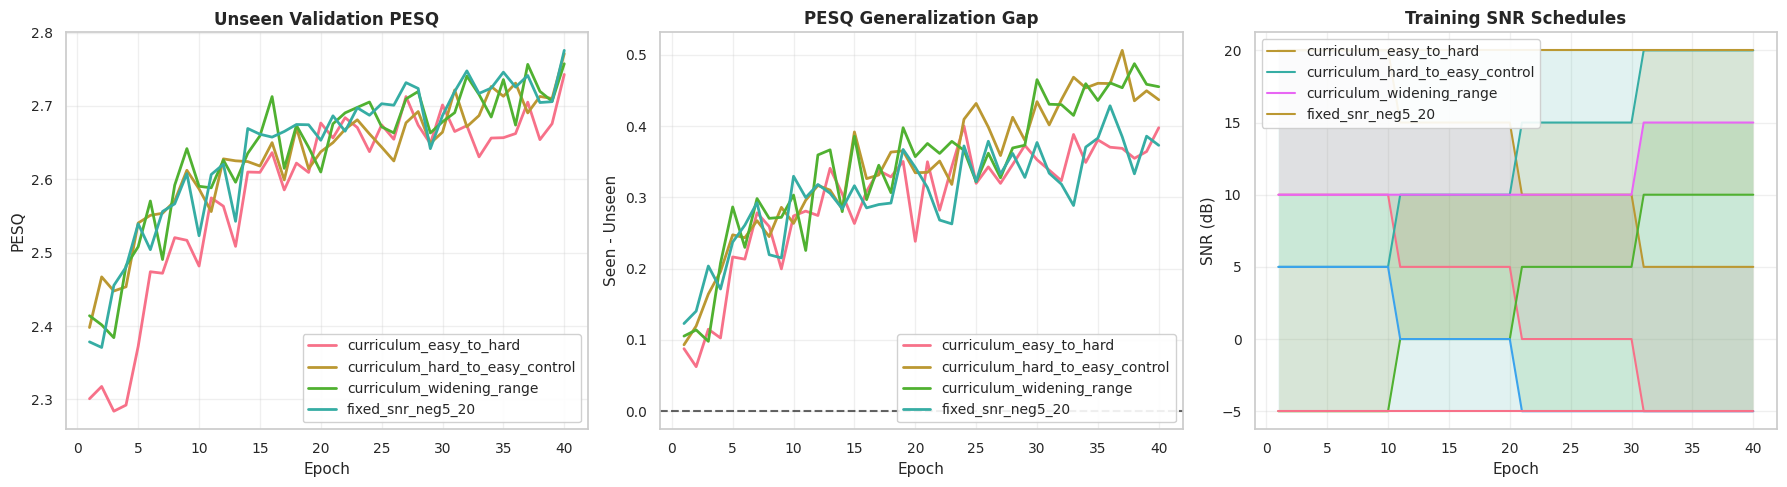

In [17]:

if len(training_histories) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for exp_name, history in training_histories.items():
        epochs = range(1, len(history["val_unseen_pesq"]) + 1)
        axes[0].plot(epochs, history["val_unseen_pesq"], label=exp_name, linewidth=2)
        axes[1].plot(epochs, history["generalization_gap_pesq"], label=exp_name, linewidth=2)
        axes[2].fill_between(epochs, history["train_snr_min"], history["train_snr_max"], alpha=0.15)
        axes[2].plot(epochs, history["train_snr_min"], linewidth=1.5)
        axes[2].plot(epochs, history["train_snr_max"], linewidth=1.5, label=exp_name)

    axes[0].set_title("Unseen Validation PESQ", fontweight='bold')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("PESQ")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("PESQ Generalization Gap", fontweight='bold')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Seen - Unseen")
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.6)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_title("Training SNR Schedules", fontweight='bold')
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("SNR (dB)")
    axes[2].grid(True, alpha=0.3)

    axes[0].legend(framealpha=0.9)
    axes[1].legend(framealpha=0.9)
    axes[2].legend(framealpha=0.9)
    plt.tight_layout()
    plt.show()


## Summary Statistics

In [19]:

if len(results_df) > 0:
    print("\n" + "=" * 90)
    print("FULLSUBNET CURRICULUM LEARNING ABLATION: BEST RESULTS BY METRIC")
    print("=" * 90)

    print(f"\nBest unseen PESQ:   {results_df.loc[results_df['unseen_pesq'].idxmax(), 'experiment']} = {results_df['unseen_pesq'].max():.3f}")
    print(f"Best unseen STOI:   {results_df.loc[results_df['unseen_stoi'].idxmax(), 'experiment']} = {results_df['unseen_stoi'].max():.3f}")
    print(f"Best unseen SI-SNR: {results_df.loc[results_df['unseen_si_snr'].idxmax(), 'experiment']} = {results_df['unseen_si_snr'].max():.3f}")

    print(f"\nSmallest PESQ gap:   {results_df.loc[results_df['gap_pesq'].abs().idxmin(), 'experiment']} = {results_df['gap_pesq'].abs().min():.3f}")
    print(f"Smallest STOI gap:   {results_df.loc[results_df['gap_stoi'].abs().idxmin(), 'experiment']} = {results_df['gap_stoi'].abs().min():.3f}")
    print(f"Smallest SI-SNR gap: {results_df.loc[results_df['gap_si_snr'].abs().idxmin(), 'experiment']} = {results_df['gap_si_snr'].abs().min():.3f}")

    print("\nRecommendations:")
    print("- If unseen PESQ is your main objective, choose the experiment with the best unseen PESQ.")
    print("- If robustness is your main objective, choose the experiment with the smallest seen-unseen gap.")
    print("- Compare both to decide whether curriculum improved robustness or only seen-domain fitting.")
